In [49]:
import matplotlib.pyplot as plt
from cryosim.plotting_tools import plot3d
from cryosim.icemaker import Icemaker
from cryosim.imagegenerator import ImageGeneratorFromCoordinates
from cryosim.progress import track
import torch
from cryosim.fft_tools import fft2, fft3
from cryosim.pdbtools import PDB
from cryosim.array_utils import center_crop

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
n = 512
dx = 0.75
im = Icemaker(n=n, dx=dx)  # keep n=256.

In [156]:
im.generate_ice_deltas()

In [157]:
im.current_icedeltas.shape

torch.Size([1, 512, 512, 512])

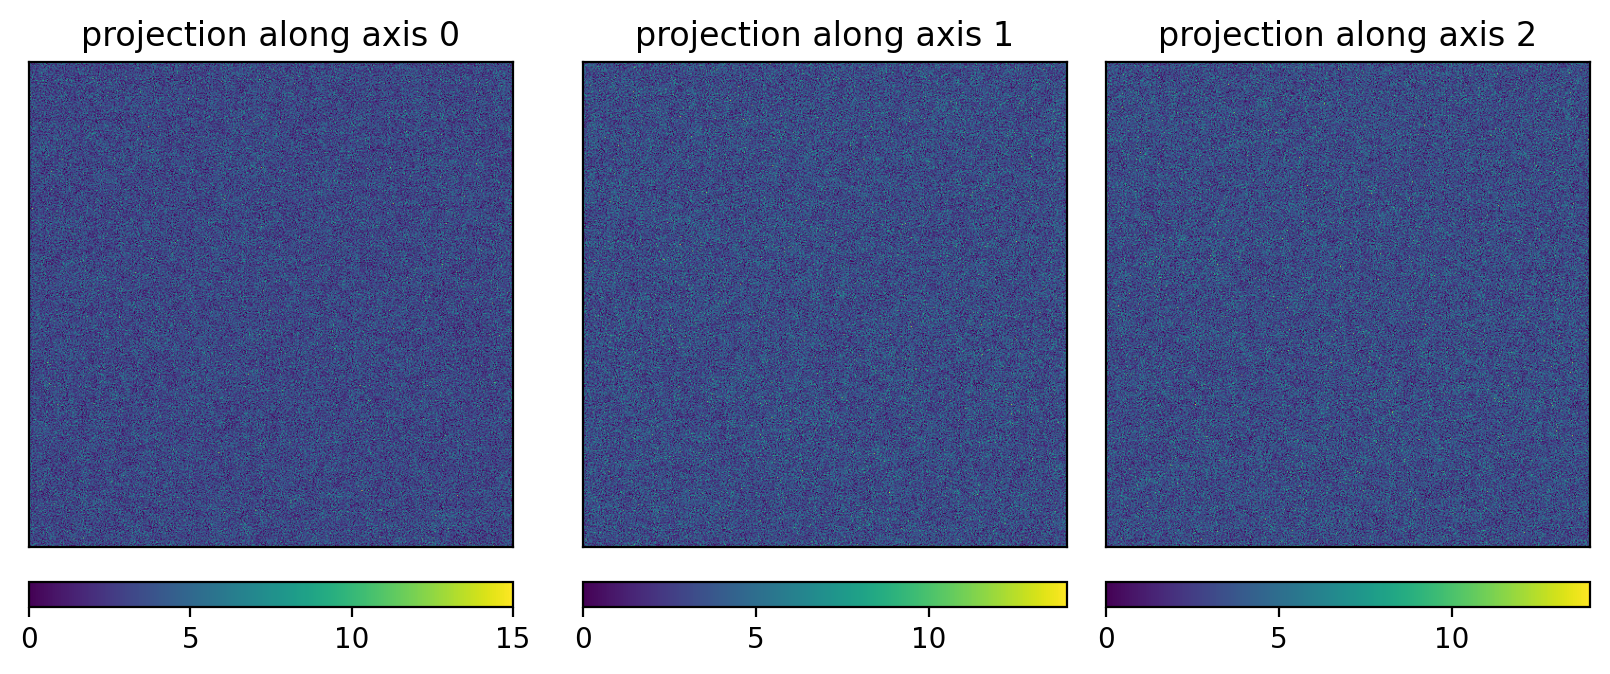

In [158]:
plot3d(im.current_icedeltas[0])

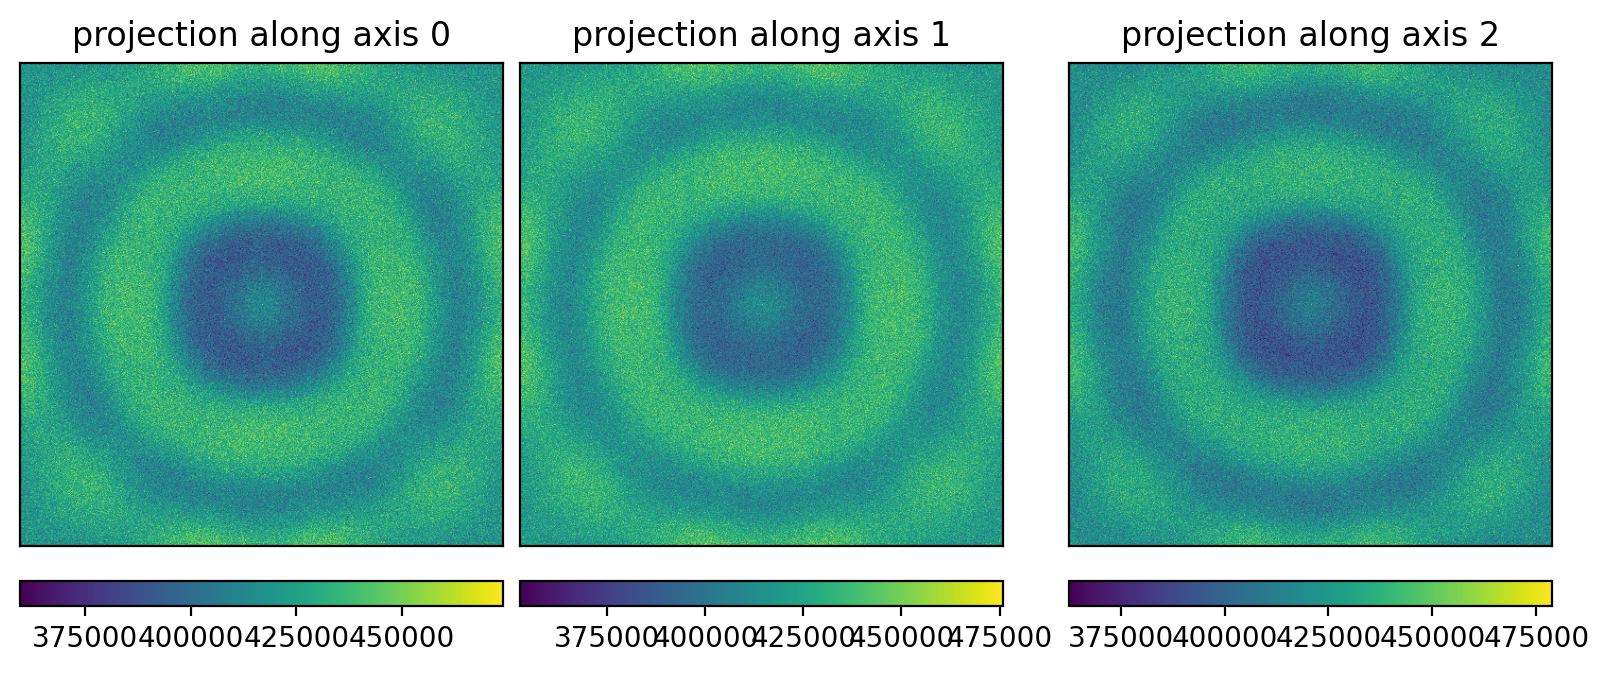

In [159]:
plot3d(
    torch.abs(
        fft3(im.current_icedeltas[0] - im.current_icedeltas[0].mean(), shift=True)
    )
)

In [160]:
coords = torch.nonzero(im.current_icedeltas[0]).float() * dx
coords = PDB.center_coordinates(coords)

In [161]:
atomic_numbers = torch.tensor([8] * len(coords))

In [196]:
n_particles = 20
energy = 300  # keV
dose_per_angstrom = 4  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [197]:
# random quaternions
quaternions = torch.tensor([[1.0, 0.0, 0.0, 0.0]])
quaternions = quaternions.repeat(n_particles, 1)

In [211]:
# random defocus
defocus_A = torch.ones(n_particles) * 7700  # angstrom
# defocus_A = torch.ones(n_particles) * 0 #angstrom


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_particles),
    "dfu": defocus_A,
}

In [212]:
# random shift. set to 0 for no shifts
shift = 0  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([20, 2])

In [213]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [234]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'

# noise_model = "poisson"  # 'poisson' or None
noise_model = None

# ice_model = "iterative"  # 'randomchoice' for fast & inaccurate, 'iterative' for slow & accurate, or None
ice_model = None

ice_thickness = (
    None  # angstroms, set to 0 for minimum ice thickness = particle box size
)

# crowd_min_distance = pdb.max_diameter # angstroms, set to None for no crowding
crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
# pad_fft = True

mean_squared_displacement_per_dose = 1.1  # A^2 per e-/A^2
# mean_squared_displacement_per_dose = 0. #A^2 per e-/A^2

model = ImageGeneratorFromCoordinates(
    coords,
    atomic_numbers,
    n,
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    conv_backend="conv3d",
    mean_squared_displacement_per_dose=mean_squared_displacement_per_dose,
).to(device)

Perturbing coordinates by: 1.1.


Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

In [235]:
idx = torch.arange(n_particles)
images = []
batchsize = 1  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/20 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

...

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

Building element ...:   0%|          | 0/1 [00:00<?, ?it/s]

torch.Size([20, 512, 512])

In [240]:
model.exitwaves.shape

torch.Size([1, 512, 512])

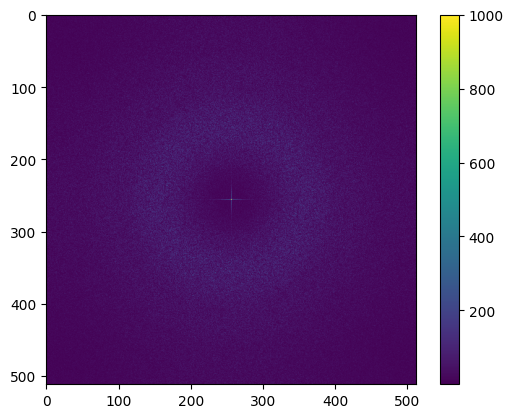

In [250]:
plt.imshow(fft2(model.exitwaves[0].abs(), shift=True).cpu().abs(), vmax=1000)
plt.colorbar()

In [236]:
images_crop = center_crop(images, 256, dim=(-2, -1))
images_crop.shape

torch.Size([20, 256, 256])

In [237]:
image_avg = torch.sum(torch.abs(fft2(images_crop, shift=True)), dim=0)

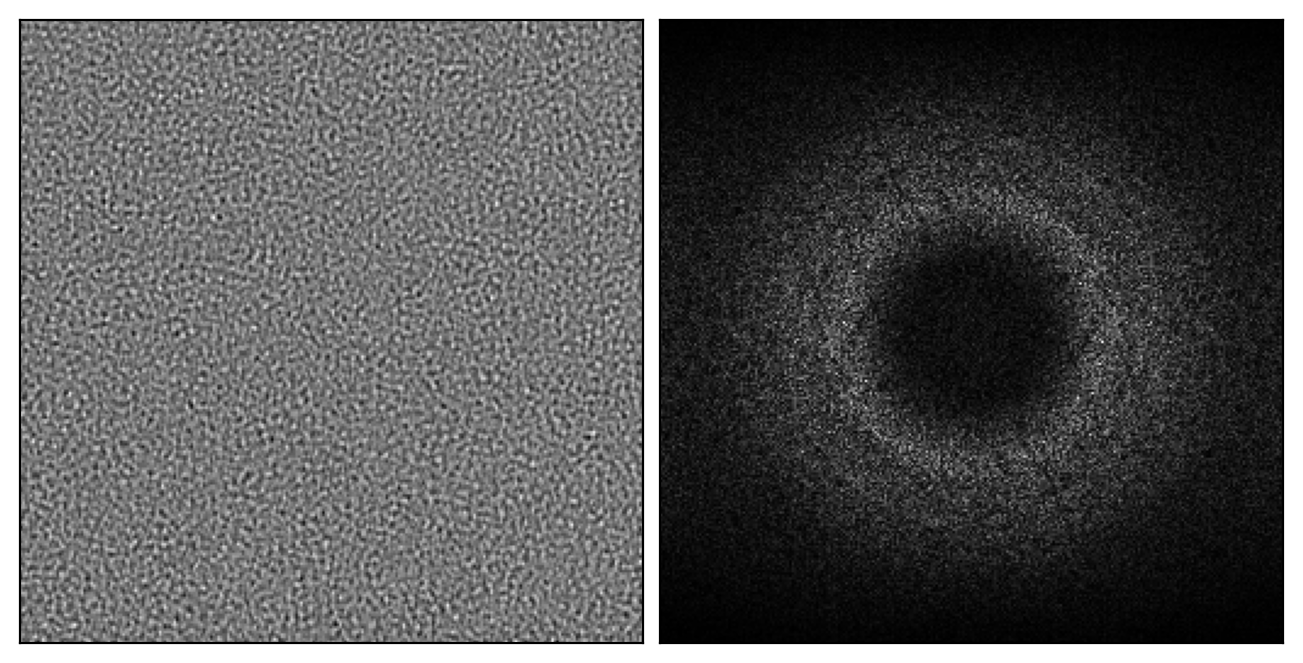

In [210]:
fig, axes = plt.subplots(1, 2, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(image_avg, cmap="grey")

ax = axes[1]
ax.imshow(torch.abs(fft2(image_avg - image_avg.mean(), shift=True)), cmap="grey")

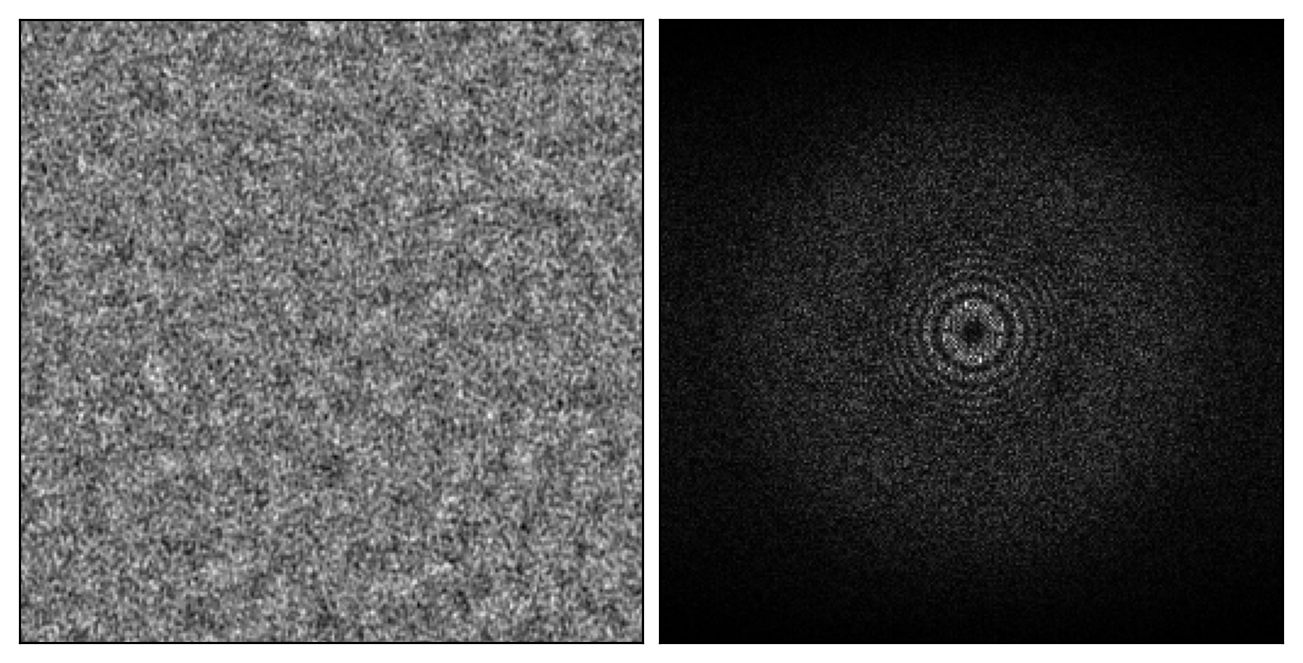

In [218]:
fig, axes = plt.subplots(1, 2, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(image_avg, cmap="grey")

ax = axes[1]
ax.imshow(torch.abs(fft2(image_avg - image_avg.mean(), shift=True)), cmap="grey")

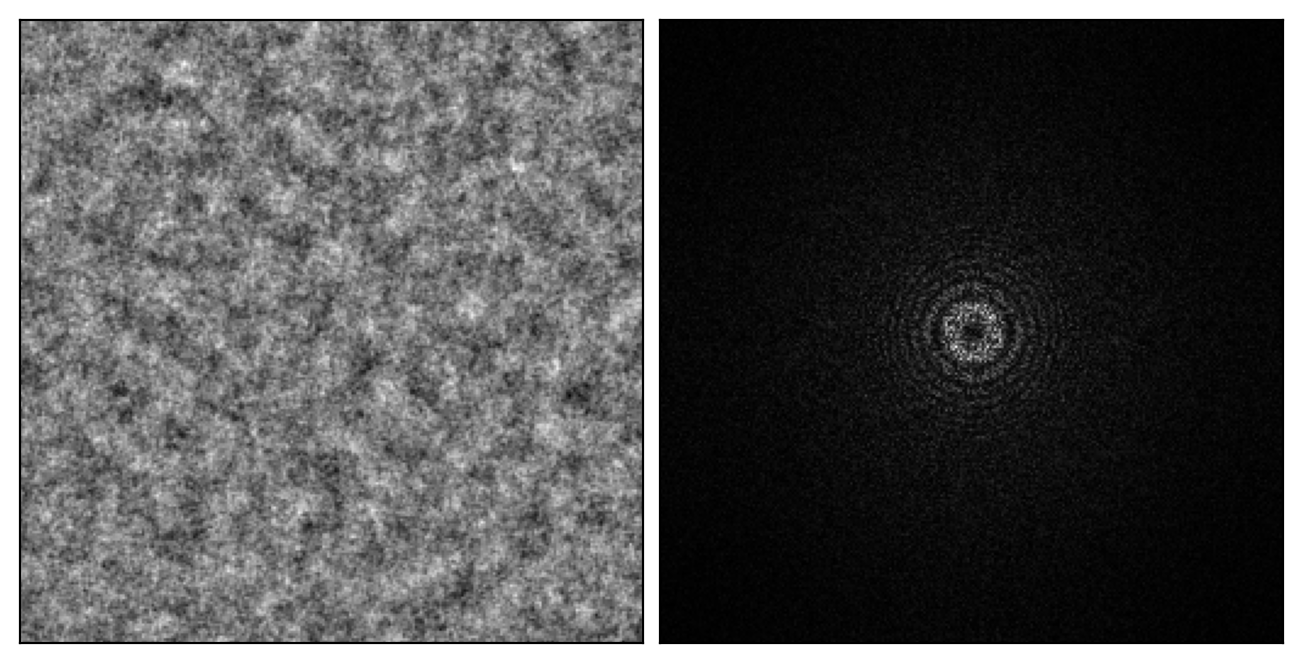

In [223]:
fig, axes = plt.subplots(1, 2, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(image_avg, cmap="grey")

ax = axes[1]
ax.imshow(torch.abs(fft2(image_avg - image_avg.mean(), shift=True)), cmap="grey")

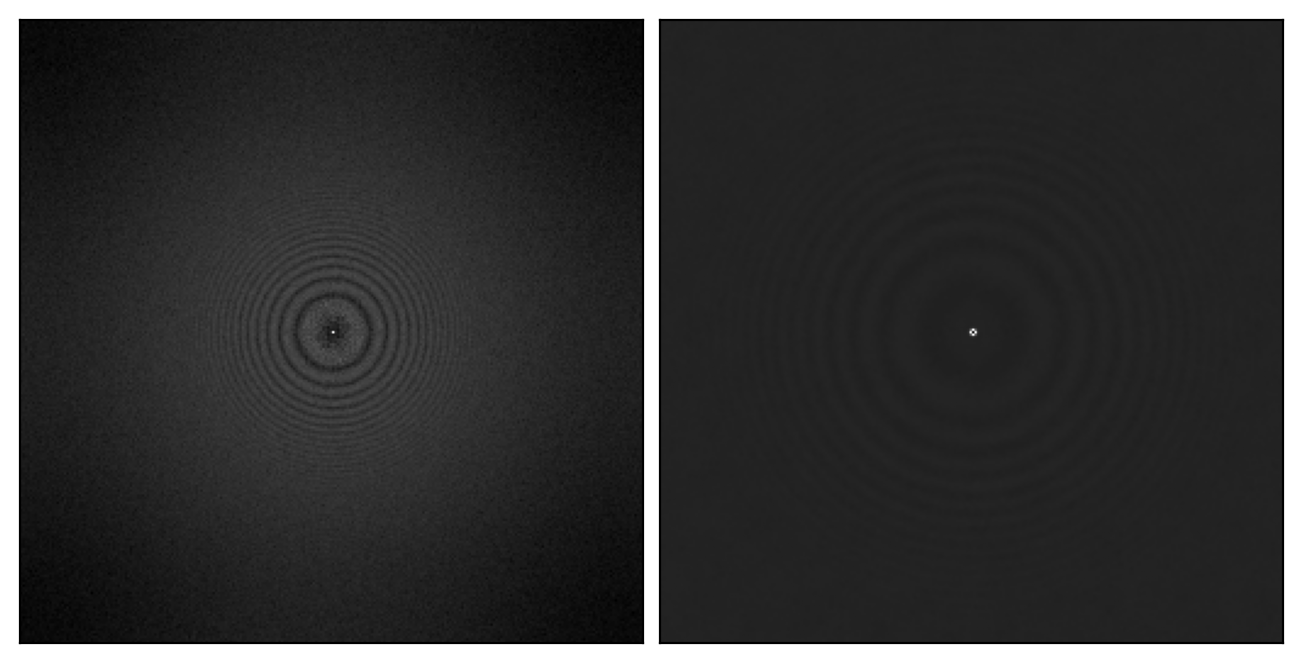

In [238]:
fig, axes = plt.subplots(1, 2, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(torch.log(image_avg), cmap="grey")

ax = axes[1]
ax.imshow(torch.abs(fft2(image_avg - image_avg.mean(), shift=True)), cmap="grey")